# Decision Analysis

## The Price is Right Problem

Two contestants guess the total value of a package of prizes. Guessing more than the prize cost causes you to lose. 

- Nate guesses 26k but the value comes in at 25,347. He loses.
- Letia guesses 21.5k and the value comes in at 21,578. She wins.
- And, because she was less than $250 off, she win's Nate's prizes as well.

For the Bayesian thinker, this poses several questions:

1. Before seeing the prizes, what prior beliefs should the contestants have about the price of the prizes?
2. After seeing the prizes, how should the contestants update those beliefs?
3. Based on the posterior distribution, what should the contestants bid?

The third question demonstrates a common use of Bayesian methods: decision analysis. 

In [9]:
import pandas as pd

def read_data(filename):
    df = pd.read_csv(filename, index_col = 0, skiprows = [1])
    return df.dropna().transpose()

In [10]:
df2011 = read_data('/Users/colelacroix/math/00.10_Think_Bayes_Downey/data/showcases.2011.csv')
df2012 = read_data('/Users/colelacroix/math/00.10_Think_Bayes_Downey/data/showcases.2012.csv')

df = pd.concat([df2011, df2012], ignore_index = True)

df.head(3)

,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0


## Kernel Density Estimation

The data set above includes prices from 313 previous showcases, a good place to start when estimating a new showcase (prior). 

Using Kernel Density Estimation (KDE), we can estimate a smooth distribution. 

In [11]:
from scipy.stats import gaussian_kde
from empiricaldist import Pmf

def kde_from_sample(sample, qs):
    """ Make a kernel density estimate from a sample """
    kde = gaussian_kde(sample)
    ps = kde(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf

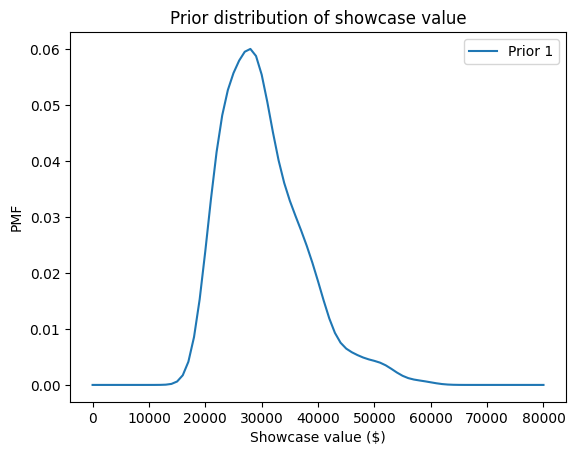

In [14]:
import numpy as np

qs = np.linspace(0, 80000, 81)
prior1 = kde_from_sample(df['Showcase 1'], qs)

import matplotlib.pyplot as plt

prior1.plot(label = 'Prior 1')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior distribution of showcase value')
plt.legend()
plt.show()

## Distribution of Error

Now that we have a prior, we have to decide: 

- What data should we use to update it?
- How should we quanitfy it?
- Can we compute a likelihood function? Meaning, can we comopute the conditional likelihood of the data?

To answer these questions, we model each contestant as a price-guessing instrument with known error characteristics. 

So we answer the question: If the actual price is 'price', what is the likelihood that the contestant's guess would be 'guess'?

Equivalently: what is the likelihood that the guess is off by 'error'?

In [15]:
# define 'error'

sample_diff1 = df['Bid 1'] - df['Showcase 1']
sample_diff2 = df['Bid 2'] - df['Showcase 2']

In [16]:
# visualize using KDE

qs = np.linspace(-40000, 20000, 61)
kde_diff1 = kde_from_sample(sample_diff1, qs)
kde_diff2 = kde_from_sample(sample_diff2, qs)

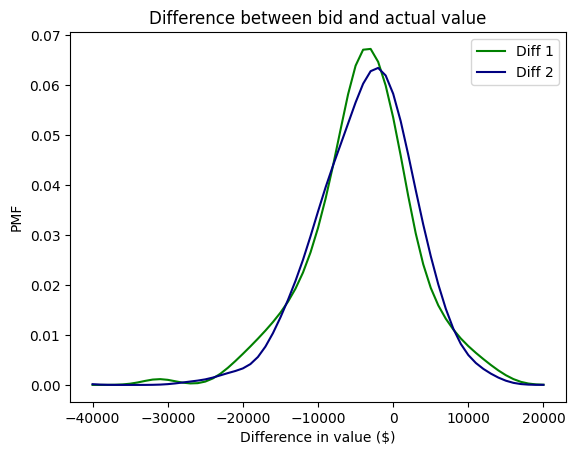

In [18]:
kde_diff1.plot(label = 'Diff 1', color = 'green')
kde_diff2.plot(label = 'Diff 2', color = 'navy')
plt.xlabel('Difference in value ($)')
plt.ylabel('PMF')
plt.title('Difference between bid and actual value')
plt.legend()
plt.show()

These distributions could be well modeled by normal distributions. So, let's summarize them with their mean and standard deviation. 

In [19]:
mean_diff1 = sample_diff1.mean()
std_diff1 = sample_diff1.std()

print(mean_diff1, std_diff1)

-4116.3961661341855 6899.909806377117


Now we can use these differences to modelt he contestants distribution of errors. But, we have to make some assumptions:

- Assume contestants underbid to be strategic, and that on average their guesses are accurate (the mean of their errors is 0).
- Assume the spread of the differences relects the sperad of their errors. So, we use the standard deviation of the differences as the standard deviation fo their errors.

Based on these assumptions, we make a normal distribution with parameters 0 and std_diff1. 

In [20]:
from scipy.stats import norm

error_dist1 = norm(0, std_diff1)

The result is a an object that provides a probability density function. 

In [21]:
# example
error = -100
error_dist1.pdf(error)

np.float64(5.781240564008691e-05)

On its own, it doesn't mean much (it's not a probability density). But they are proportional to probabilities, so we can use them as likelihoods. 

## Update

Imagine I'm player 1. I guess the value of a showcase at $23,000. From the guess we subtract each hypothetical price in the distribution, giving us the error under each hypothesis. 

In [22]:
guess1 = 23000
error1 = guess1 - prior1.qs

Suppose also that based on past performance, our estimation is well modeled by error_dist1. Under that assumption, we can compute the likelihood of your error under each hypothesis:

In [23]:
likelihood1 = error_dist1.pdf(error1)

The result is an array of likelihoods that we can use to update the prior:

In [24]:
posterior1 = prior1 * likelihood1
posterior1.normalize()

np.float64(3.3889812097254624e-05)

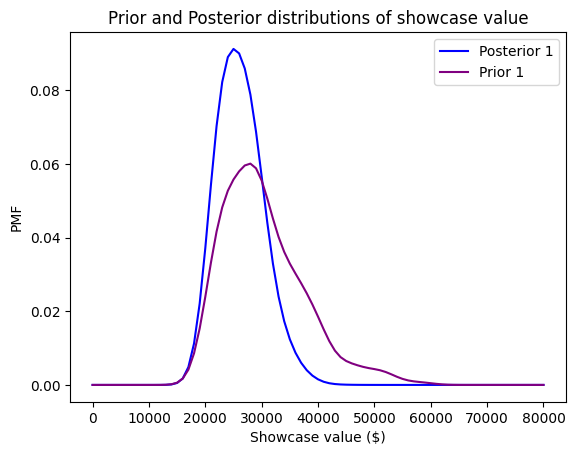

In [33]:
posterior1.plot(label = 'Posterior 1', color = 'blue')
prior1.plot(label = 'Prior 1', color = 'purple')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior and Posterior distributions of showcase value')
plt.legend()
plt.show()

In [52]:
# player 2

qs = np.linspace(0, 80000, 81)
prior2 = kde_from_sample(df['Showcase 2'], qs)

mean_diff2 = sample_diff2.mean()
std_diff2 = sample_diff2.std()

print(mean_diff2, std_diff2)

-3675.891373801917 6886.260711323408


In [53]:
from scipy.stats import norm

error_dist2 = norm(0, std_diff2)

In [54]:
guess2 = 38000
error2 = guess2 - prior2.qs

In [55]:
likelihood2 = error_dist2.pdf(error2)

In [56]:
posterior2 = prior2 * likelihood2
posterior2.normalize()

np.float64(2.6978123219107025e-05)

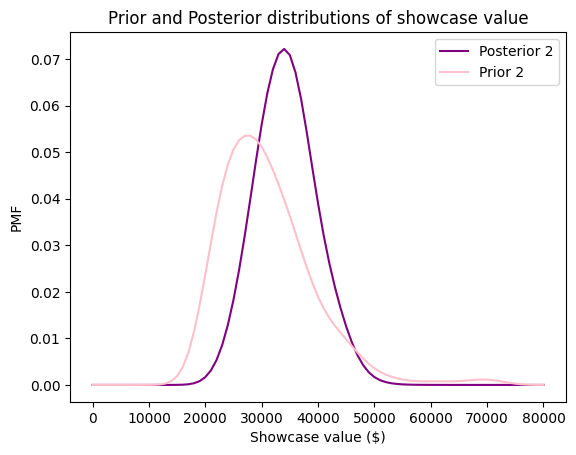

In [57]:
posterior2.plot(label = 'Posterior 2', color = 'purple')
prior2.plot(label = 'Prior 2', color = 'pink')
plt.xlabel('Showcase value ($)')
plt.ylabel('PMF')
plt.title('Prior and Posterior distributions of showcase value')
plt.legend()
plt.show()

## Probability of Winning

Now that we have posterior distributions for each player, let's strategize. 

From the perspective of Player 1, let's compute the probability that Player 2 overbids. To simplify, we only use past player performance and ignore showcase value. 

In [58]:
def prob_overbid(sample_diff):
    """ Compute the probability of overbid."""
    return np.mean(sample_diff > 0)

In [60]:
# probability of player 2 overbid
prob_overbid(sample_diff2)

np.float64(0.29073482428115016)

Now suppose that Player 1 underbids by $5,000. What is the probability taht Player 2 underbids more?

In [62]:
def prob_worse_than(diff, sample_diff):
    """" Probability opponent diff is worse than given diff."""
    return np.mean(sample_diff < diff)

In [64]:
# prob that player 2 underbids by more than $5,000

prob_worse_than(-5000, sample_diff2)

np.float64(0.38338658146964855)

In [66]:
# prob that player 2 underbids by more thank $10,000

prob_worse_than(-10000, sample_diff2)

np.float64(0.14376996805111822)

We can combine these functions to compute the probability that Player 1 wins given the difference between their bid an the actual price:

In [67]:
def compute_prob_win(diff, sample_diff):
    """Probability of winning for a given diff"""
    # you lose if you overbid
    if diff > 0:
        return 0

    # if the opponent overbids, you win
    p1 = prob_overbid(sample_diff)

    # or if their bid is worse than yours
    p2 = prob_worse_than(diff, sample_diff)

    # p1 and p2 are mutually exclusive, so we can add them
    return p1 + p2

In [84]:
# prob player 1 wins given I underbid $5000

compute_prob_win(-5000, sample_diff2)

np.float64(0.6741214057507987)

Now let's look at a range of possibilites:

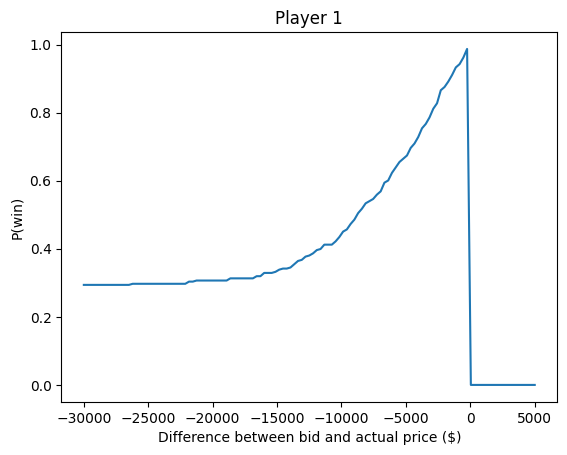

In [85]:
xs = np.linspace(-30000, 5000, 121)
ys = [compute_prob_win(x, sample_diff2)
      for x in xs]

plt.plot(xs, ys)
plt.xlabel("Difference between bid and actual price ($)")
plt.ylabel("P(win)")
plt.title("Player 1")
plt.show()

## Decision Analysis

In the last section we estimated the probablity of winning given that we underbid by a certain amount. But, in reality contestants don't know how much they have underbid by, because they dont know the actual price. 

They do, however, have a posterior distribution that represents their beliefs abou the actual price, and they can use that to estimate their probability of winning with a given bid. 

This next function takes a possible bid, a posterior distribution of actual prices, and a sample of differences for the opponent to loop through hypothetical prices in the posterior distribution and for each price:

- Compute the difference between the bid and the hypotheical price,
- Compute the probability that the player wins, given that differences, and
- Adds up the weighted sum of the probabilities, where the weights are the probabilities in the posterior distribution. 

In [86]:
def total_prob_win(bid, posterior, sample_diff):
    """ Computes the total probability fo winning with a given bid. 

    bid: your bid
    posterior: Pmf of showcase value
    sample_diff: sequence of differences for the opponent

    returns: probability of winning"""

    total = 0
    for price, prob in posterior.items():
        diff = bid - price
        total += prob * compute_prob_win(diff, sample_diff)
    return total

This loop implements the law of total probability:

$$ P\,(win) = \sum_{price} \; P(price) \, P(win \, | \, price) $$

In [87]:
# prob that player 1 wins based on bid of $25000

total_prob_win(25000, posterior1, sample_diff2)

np.float64(0.4842210945439812)

In [88]:
# now loop through a series of possible bids 

bids = posterior1.qs

probs = [total_prob_win(bid, posterior1, sample_diff2)
         for bid in bids]

prob_win_series = pd.Series(probs, index = bids)

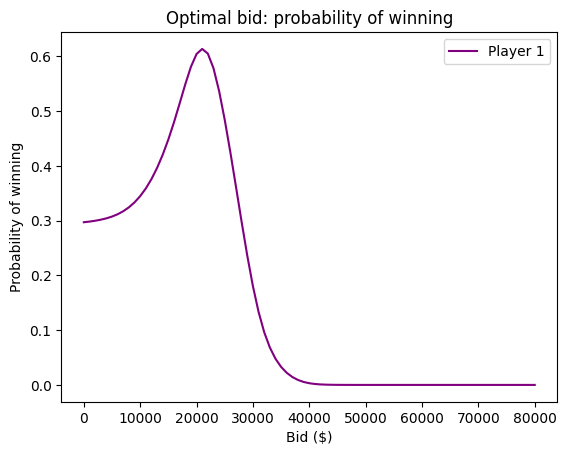

In [90]:
prob_win_series.plot(label = 'Player 1', color = 'purple')
plt.xlabel('Bid ($)')
plt.ylabel('Probability of winning')
plt.title('Optimal bid: probability of winning')
plt.legend()
plt.show()

In [91]:
# find bid that maximizes probability of winning

prob_win_series.idxmax()

np.float64(21000.0)

In [92]:
prob_win_series.max()

np.float64(0.6136807192359474)

So, recall that Player 1's guess was 23,000. Using the guess and prior data to compute a posterior, the posterior mean is about 26,000. But, the bid that maximizes the probability of winning is 21000. 

## Maximizing Expected Gain

In the last section we computed the bid that maximizes your chances of winning. If that's the goal, then we have the answer. 

But, remember that if the bid is off by less than $250, you win both showcases. So increasing the bid increases your chances of losing but it also increases the possible reward. 

This function computes how much you will win, on average, given your bid, the actual price, and a sample of errors for your opponent:

In [93]:
def compute_gain(bid, price, sample_diff):
    """ Compute expected gain given a bid and actual price. """
    diff = bid - price
    prob = compute_prob_win(diff, sample_diff)

    # if you are within 250 dollars, you win both
    if -250 <= diff <= 0:
        return 2 * price * prob
    else:
        return price * prob

So, if the actual price is 35k and we bid 30k, we will win about:

In [94]:
compute_gain(30000, 35000, sample_diff2)

np.float64(23594.249201277955)

In reality, we dont know the actual price. But we have a posterior distribution that represents what we know about it. By averaging over the prices and probabilites in the posterior distribution, we can compute the expected gain for a particular bid. In this context, 'expected' means the average over the possible showcase values weighted by their probabilities. 

In [95]:
def expected_gain(bid, posterior, sample_diff):
    """ Compute the expected gain of a given bid. """
    total = 0
    for price, prob in posterior.items():
        total += prob * compute_gain(bid, price, sample_diff)
    return total

In [96]:
expected_gain(21000, posterior1, sample_diff2)

np.float64(16923.599338565116)

For the posterior we computed earlier, based on a guess of 23k, the expected gain for a bid of 21k si about 16.9k. 

Can we do any better? 

To find out, we can loop through a range of bids  and find the one that maximizes expected gain:

In [97]:
bids = posterior1.qs

gains = [expected_gain(bid, posterior1, sample_diff2) for bid in bids]

expected_gain_series = pd.Series(gains, index = bids)

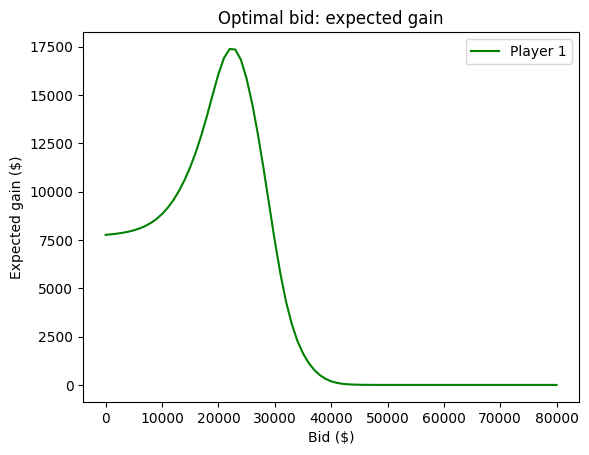

In [100]:
expected_gain_series.plot(label = 'Player 1', color = 'green')
plt.xlabel('Bid ($)')
plt.ylabel('Expected gain ($)')
plt.title('Optimal bid: expected gain')
plt.legend()
plt.show()

In [101]:
# optimal bid

expected_gain_series.idxmax()

np.float64(22000.0)

In [102]:
# expected gain with that max

expected_gain_series.max()

np.float64(17384.899584430794)

## Summary

1. Used KDE and data from past shows to estimate priors for showcase values
2. Then used bids from past shows to model a distribution of errors
3. Performed Bayesian update using the distribution of errors to compute likelihood
4. Used posterior for showcase value to compute the probability fo winning for each possible bid and identified the max probability bid
5. Used probability for winning to compute the expected gain for each possible bid and identifed the bid that maximizes expected gain 